## Data Context 

The dataset used in this thesis is the manually annotated gold standard dataset introduced by Bos et al., which contains reference mentions from Dutch parliamentary debates and their corresponding linked governmental documents.

Each entry represents a reference found in parliamentary proceedings, along with its surrounding context (sentence and paragraph) and metadata about the referenced document, such as document type and identifiers. The dataset is designed to support research on detecting and linking implicit references, where references are often expressed as short descriptive phrases rather than explicit document identifiers.

### Additional Dataset

In addition to the annotated dataset by Bos et al., an additional dataset may be used later in the thesis to support evaluation and comparison of retrieval performance. Ideally, this dataset should be publicly available and include similar tasks or benchmarks for document retrieval.

Using a second dataset can provide a useful point of reference for evaluating model performance. If results differ significantly between datasets, this may help identify limitations or biases in the primary dataset and guide further analysis.

# Data Description

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from rank_bm25 import BM25Okapi

### Data Loading

In [2]:
df = pd.read_csv("annotated-dataset.csv")

df.shape

(189, 15)

The annotated dataset contains 189 reference mentions and 15 variables describing the reference, its context, and the linked document metadata.

### Dataset Overview

In [3]:
df.head()

,task_id,minute_id,annotation_id,start_xpath,end_xpath,text,reference_type,external_identifier,external_url,document_type,referenced_annotation_id,start_char,end_char,sentence,paragraph
0,20,h-tk-20072008-2932-2933,eqX-E4hNLj,/div[2]/div[2]/p[1]/text()[1],/div[2]/div[2]/p[1]/text()[1],"stuk nr. 12, I",explicit-parl-doc,kst-31226-12,https://zoek.officielebekendmakingen.nl/kst-31...,Amendement,NaN,728,742,In stemming komt het amendement-Blok (stuk nr....,In stemming komt het amendement-Blok (stuk nr....
1,20,h-tk-20072008-2932-2933,9-LM719yfG,/div[2]/div[3]/p[2]/text()[1],/div[2]/div[3]/p[2]/text()[1],dit amendement,impl-local,kst-31226-12,NaN,NaN,eqX-E4hNLj,851,865,Ik constateer dat de aanwezige leden van de fr...,Ik constateer dat de aanwezige leden van de fr...
2,20,h-tk-20072008-2932-2933,14EucRGIYO,/div[2]/div[3]/p[3]/text()[1],/div[2]/div[3]/p[3]/text()[1],dit amendement,impl-local,kst-31226-12,NaN,NaN,eqX-E4hNLj,1000,1014,Ik stel vast dat door de verwerping van dit am...,Ik stel vast dat door de verwerping van dit am...
3,20,h-tk-20072008-2932-2933,mSHOrGgm4Z,/div[2]/div[3]/p[3]/text()[1],/div[2]/div[3]/p[3]/text()[1],het andere op stuk nr. 12 voorkomende amendement,impl-local,kst-31226-12,NaN,NaN,eqX-E4hNLj,1014,1063,Ik stel vast dat door de verwerping van dit am...,Ik stel vast dat door de verwerping van dit am...
4,20,h-tk-20072008-2932-2933,eqX-E4hNLj,/div[2]/div[2]/p[1]/text()[1],/div[2]/div[2]/p[1]/text()[1],"stuk nr. 12, I",explicit-parl-doc,kst-31226-12,https://zoek.officielebekendmakingen.nl/kst-31...,Amendement,NaN,728,742,In stemming komt het amendement-Blok (stuk nr....,In stemming komt het amendement-Blok (stuk nr....


The annotated dataset contains 189 reference mentions and 15 variables describing the reference, its context, and the linked document metadata.

### Dataset Structure

In [4]:
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   task_id                   189 non-null    int64 
 1   minute_id                 189 non-null    object
 2   annotation_id             189 non-null    object
 3   start_xpath               189 non-null    object
 4   end_xpath                 189 non-null    object
 5   text                      189 non-null    object
 6   reference_type            189 non-null    object
 7   external_identifier       167 non-null    object
 8   external_url              72 non-null     object
 9   document_type             73 non-null     object
 10  referenced_annotation_id  103 non-null    object
 11  start_char                189 non-null    int64 
 12  end_char                  189 non-null    int64 
 13  sentence                  189 non-null    object
 14  paragraph                 

task_id                       0
minute_id                     0
annotation_id                 0
start_xpath                   0
end_xpath                     0
text                          0
reference_type                0
external_identifier          22
external_url                117
document_type               116
referenced_annotation_id     86
start_char                    0
end_char                      0
sentence                      0
paragraph                     0
dtype: int64

The dataset contains 189 annotated reference mentions described by 15 variables. These variables include identifiers, reference text, contextual information (sentence and paragraph), and metadata about the referenced documents.

Most variables are of type object, indicating textual or categorical data, while a few variables such as task_id, start_char, and end_char are numerical.

An inspection of missing values shows that the core fields required for retrieval experiments — such as text, sentence, and paragraph — are complete. However, some metadata-related fields contain missing values. In particular:

external_identifier has 22 missing values
external_url has 117 missing values
document_type has 116 missing values
referenced_annotation_id has 86 missing values

This suggests that while the reference text and context are reliable, metadata is only partially available. This is an important observation, as it may influence the effectiveness of metadata-based retrieval methods explored later in the thesis.

### Reference Length Analysis

In [5]:
df["reference_length"] = df["text"].apply(lambda x: len(str(x).split()))
df["reference_length"].describe()

count    189.000000
mean       2.492063
std        2.282261
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max       25.000000
Name: reference_length, dtype: float64

Text(0.5, 1.0, 'Distribution of Reference Lengths')

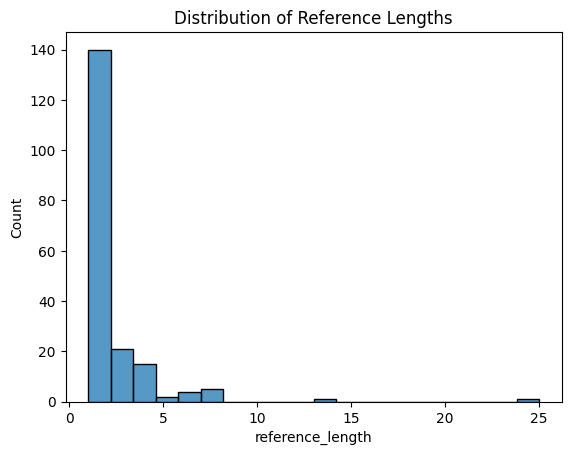

In [6]:
sns.histplot(df["reference_length"], bins=20)
plt.title("Distribution of Reference Lengths")

The length of reference mentions varies across the dataset. On average, references contain approximately 2.5 words, with most references consisting of only 1 to 3 words. The distribution is highly skewed towards shorter references, with only a few longer phrases.

This indicates that many references are short and underspecified, often lacking explicit identifiers or detailed descriptions of the target document. As a result, purely lexical retrieval methods such as BM25 may struggle to retrieve the correct document, especially in cases where multiple documents share similar terminology.

These observations motivate the use of semantic retrieval methods and neural reranking models, which are better suited to capture contextual meaning beyond surface-level word overlap.

### Reference Type Analysis  

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'impl-local'),
  Text(1, 0, 'explicit-parl-doc'),
  Text(2, 0, 'impl-ext-third-party'),
  Text(3, 0, 'impl-ext-parl-doc'),
  Text(4, 0, 'explicit-dossier'),
  Text(5, 0, 'impl-ext-dossier')])

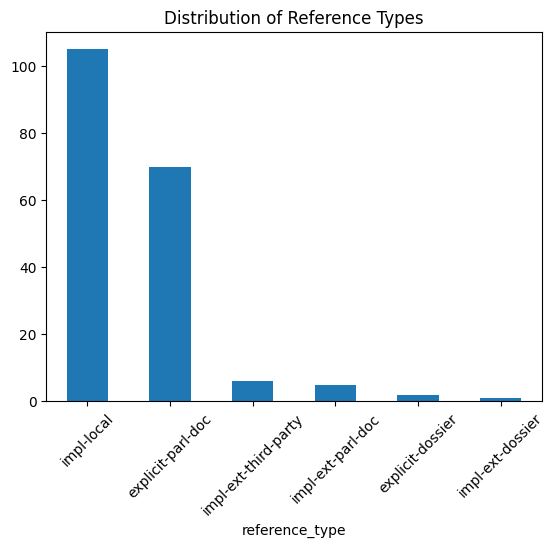

In [7]:
df["reference_type"].value_counts()
df["reference_type"].value_counts().plot(kind="bar")
plt.title("Distribution of Reference Types")
plt.xticks(rotation=45)

The distribution of reference types shows that the dataset is dominated by implicit references, particularly *impl-local*, followed by *explicit-parl-doc*. Other categories such as *impl-ext-third-party*, *impl-ext-parl-doc*, and *explicit-dossier* appear only rarely.

This indicates that a large portion of the dataset consists of implicit references, which are generally more difficult to resolve because they lack explicit identifiers. In contrast, explicit references, such as *explicit-parl-doc*, are easier to link due to the presence of structured information like document numbers.

The imbalance between implicit and explicit reference types highlights the complexity of the task. Since implicit references form the majority, retrieval models must rely heavily on contextual and semantic understanding rather than simple lexical matching.

These findings further support the need for advanced retrieval approaches, such as dense retrieval and neural reranking, which are better suited to handle implicit and context-dependent references.

### Document Type Analysis 

In [8]:
df["document_type"].value_counts()

document_type
Brief               39
Motie               19
Amendement          13
Overig               1
Voorstel van wet     1
Name: count, dtype: int64

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Brief'),
  Text(1, 0, 'Motie'),
  Text(2, 0, 'Amendement'),
  Text(3, 0, 'Overig'),
  Text(4, 0, 'Voorstel van wet')])

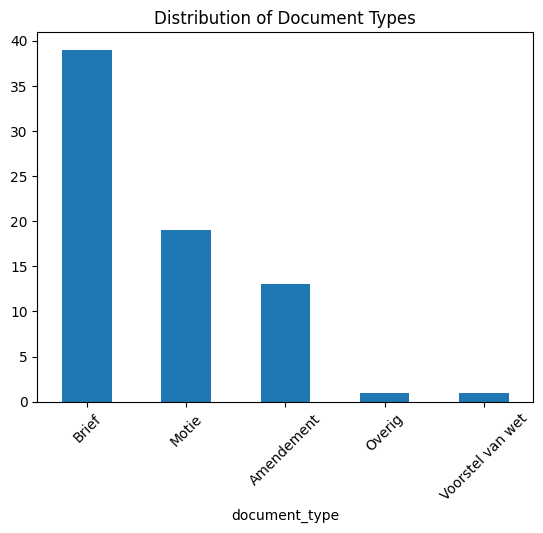

In [9]:
df["document_type"].value_counts().plot(kind="bar")
plt.title("Distribution of Document Types")
plt.xticks(rotation=45)

The distribution of document types shows that the majority of references point to a small number of categories. In particular, Brief (39 instances), Motie (19 instances), and Amendement (13 instances) are the most frequently referenced document types, while other categories such as Overig and Voorstel van wet appear only rarely.

This indicates a clear imbalance in the dataset, where certain document types dominate the references. From a retrieval perspective, this suggests that models may perform better on frequently occurring document types, while struggling with less common ones due to limited examples.

Additionally, document type could serve as a useful signal for narrowing down candidate documents during retrieval. For example, if a reference is likely to correspond to a motion (Motie), filtering candidates by document type could improve efficiency and accuracy. However, as observed earlier, metadata fields are not always complete, which may limit the applicability of such filtering strategies.

Overall, these findings highlight both the potential and the limitations of using document type as a feature in retrieval and reranking models.

### Context Analysis

In [10]:
df["sentence_length"] = df["sentence"].apply(lambda x: len(str(x).split()))

df["sentence_length"].describe()

count    189.000000
mean      51.788360
std       40.956096
min        3.000000
25%       20.000000
50%       53.000000
75%       62.000000
max      207.000000
Name: sentence_length, dtype: float64

Text(0.5, 1.0, 'Distribution of Sentence Lengths')

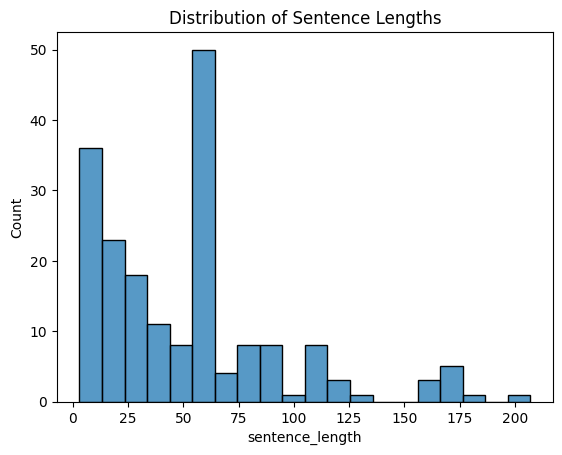

In [11]:
sns.histplot(df["sentence_length"], bins=20)
plt.title("Distribution of Sentence Lengths")

The sentence context surrounding each reference is substantially longer than the reference itself. On average, sentences contain approximately 52 words, with a wide distribution ranging from very short sentences to sentences exceeding 200 words.

This indicates that while reference mentions are typically short and underspecified, the surrounding sentence often provides significantly richer contextual information. This additional context may be crucial for correctly interpreting the meaning of the reference.

From a retrieval perspective, this suggests that incorporating contextual information could improve performance, particularly for implicit references. While lexical retrieval methods may struggle with short reference queries, neural reranking models can leverage sentence-level context to better disambiguate between candidate documents.

### Data Quality Analysis

In [12]:
df.duplicated().sum()

np.int64(49)

The dataset contains 49 duplicate entries. This indicates that some references appear multiple times, possibly due to repeated mentions within the same debate or annotation artifacts.

The presence of duplicates may influence evaluation results, as repeated instances of the same reference could bias performance metrics. Therefore, it is important to be aware of this when designing experiments.

In this analysis, duplicates are retained to preserve the original dataset structure. However, their impact will be considered during evaluation and error analysis.

### Key Observations

The exploratory data analysis reveals several important characteristics of the dataset:

1. **Short and underspecified references**  
Most reference mentions are very short (typically 1–3 words), making it difficult for purely lexical retrieval methods to identify the correct document.

2. **Rich contextual information**  
The surrounding sentence context is significantly longer and provides additional semantic information that may help disambiguate references.

3. **Imbalanced document types**  
Certain document types, such as *Brief* and *Motie*, dominate the dataset, which may influence retrieval performance and introduce bias.

4. **Incomplete metadata**  
Metadata fields such as `document_type` and `external_identifier` are not always available, which may limit the effectiveness of metadata-based retrieval strategies.

5. **Presence of duplicate entries**  
A notable number of duplicate references exist in the dataset, which may affect evaluation and should be considered during analysis.

These observations motivate the design choices in this thesis, including the use of hybrid retrieval methods and neural reranking models to handle ambiguous and context-dependent references.

### Baseline Retrieval (BM25)

To establish a simple baseline for the retrieval task, a BM25-based approach is used. In this setup, reference mentions are treated as queries, and the surrounding sentences are used as a proxy for candidate documents.

Although this is a simplified setup, it provides an initial indication of how well lexical retrieval performs on this dataset.

In [13]:
corpus = list(set(df["sentence"].astype(str).tolist()))
tokenized_corpus = [doc.split() for doc in corpus]

bm25 = BM25Okapi(tokenized_corpus)

In [14]:
query = df["text"].iloc[0]
tokenized_query = query.split()

scores = bm25.get_scores(tokenized_query)

In [15]:
top_n = np.argsort(scores)[::-1][:5]

for i in top_n:
    print("Score:", scores[i])
    print("Doc:", corpus[i])
    print("-----")

Score: 9.596986519176161
Doc: In stemming komt het amendement-Blok (stuk nr. 12, I).
-----
Score: 7.471382323241162
 VI) en de gewijzigde amendementen-Omtzigt/Hamer (stuk nrs. 17, I en II).tn
-----
Score: 7.414644223508096
 nr. 12 voorkomende amendement als verworpen kan worden beschouwd.dere op stuk
-----
Score: 7.103358868352071
 kan worden beschouwd.. 33 voorkomende nader gewijzigde amendement als aangenomen
-----
Score: 3.3229605006969876
Doc: Zij krijgt nr.
-----


#### Baseline Results and Interpretation

The BM25 baseline retrieves sentences based on lexical overlap with the reference query. The top results show that the model is able to identify sentences that contain similar terms to the query.

However, the retrieved results also highlight some limitations. While the top-ranked sentences are relevant, they rely heavily on exact word overlap and may not capture deeper semantic meaning. This becomes problematic when references are short or expressed differently from the original document.

These findings suggest that while BM25 provides a reasonable starting point, more advanced methods such as dense retrieval and neural reranking are needed to better handle implicit and context-dependent references.